## 1. Introdução

Em problemas de **classificação**, normalmente temos exemplos com rótulos conhecidos.

Exemplo:

| Idade | Renda | Classe |
|---|---:|---|
| 22 | 1800 | Baixo risco |
| 45 | 7000 | Alto risco |

Já em problemas de **agrupamento**, os dados não possuem rótulos. O objetivo é encontrar estruturas ou grupos naturais nos dados.

Exemplo:

| Idade | Renda |
|---:|---:|
| 22 | 1800 |
| 45 | 7000 |
| 30 | 2500 |
| 50 | 9000 |

O algoritmo tenta responder perguntas como:

- Existem grupos parecidos?
- Quais pontos são semelhantes entre si?
- Há pontos muito diferentes dos demais?
- Os dados parecem formar grupos separados?

Nesta aula vamos trabalhar com dois algoritmos:

1. **K-Means**: agrupa os pontos com base na distância até centros chamados centroides.
2. **DBSCAN**: agrupa pontos com base em regiões de alta densidade e consegue identificar ruídos/outliers.


In [20]:
# Importando as bibliotecas necessárias

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)


## 2. Criando uma função auxiliar para visualização

Para evitar repetir código, criaremos uma função para mostrar os pontos em um gráfico 2D.

A função pode mostrar os pontos sem agrupamento ou coloridos de acordo com os grupos encontrados por algum algoritmo.


In [21]:
def plot_clusters(X, labels=None, centroids=None, title="Visualização dos dados"):
    plt.figure(figsize=(7, 5))

    if labels is None:
        plt.scatter(X[:, 0], X[:, 1], s=40)
    else:
        plt.scatter(X[:, 0], X[:, 1], c=labels, s=40)

    if centroids is not None:
        plt.scatter(
            centroids[:, 0],
            centroids[:, 1],
            marker="X",
            s=250,
            label="Centroides"
        )
        plt.legend()

    plt.title(title)
    plt.xlabel("Atributo 1")
    plt.ylabel("Atributo 2")
    plt.grid(True)
    plt.show()


# Parte 1 — K-Means

## 3. Criando um conjunto de dados simples

Primeiro, vamos criar dados artificiais com três grupos bem separados.

Esse tipo de dado favorece o funcionamento do K-Means, porque os grupos têm formato aproximadamente circular e estão relativamente separados.


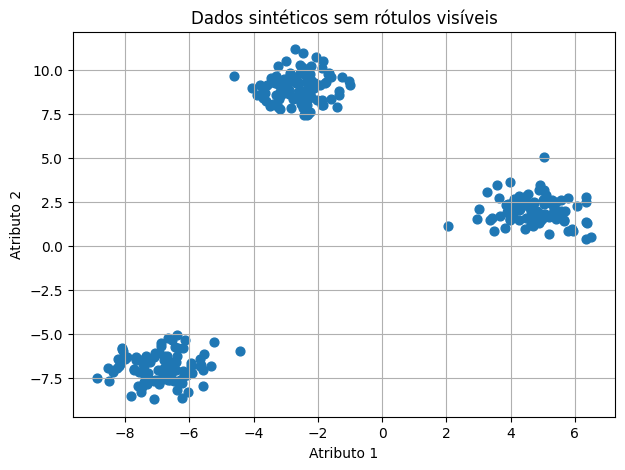

In [25]:
X_blobs, y_blobs = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.8,
    random_state=42
)

plot_clusters(X_blobs, title="Dados sintéticos sem rótulos visíveis")


## 4. Aplicando o K-Means

O K-Means precisa receber previamente o número de grupos desejado.

O parâmetro mais importante é:

- `n_clusters`: quantidade de grupos que o algoritmo deve encontrar.

Nesta primeira execução, usaremos `n_clusters=3`, porque visualmente os dados parecem ter três grupos.


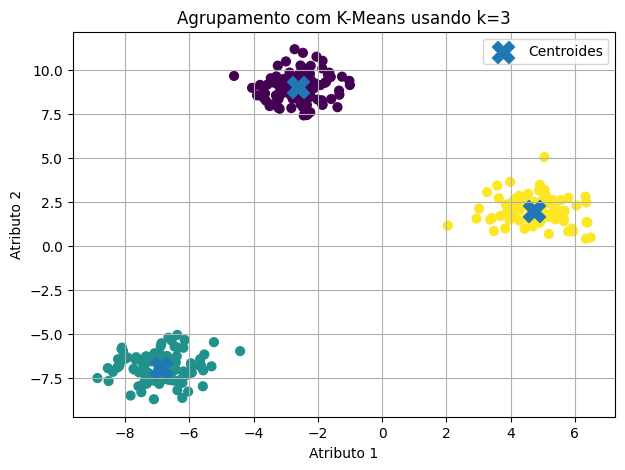

In [26]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_blobs)
centroids = kmeans.cluster_centers_

plot_clusters(
    X_blobs,
    labels=labels_kmeans,
    centroids=centroids,
    title="Agrupamento com K-Means usando k=3"
)


## 5. Como o K-Means funciona?

De forma simplificada, o K-Means executa os seguintes passos:

1. Escolhe inicialmente alguns centroides.
2. Associa cada ponto ao centroide mais próximo.
3. Recalcula os centroides com base nos pontos atribuídos a cada grupo.
4. Repete os passos 2 e 3 até estabilizar.

A ideia é minimizar a distância dos pontos até o centroide do seu grupo.

No scikit-learn, essa medida aparece no atributo `inertia_`.

Quanto menor a inércia, mais próximos os pontos estão dos centroides. Porém, uma inércia menor nem sempre significa melhor modelo, porque aumentar o número de grupos tende naturalmente a reduzir a inércia.


In [ ]:
print("Inércia do modelo:", kmeans.inertia_)
print("Centroides encontrados:")
print(centroids)


## 6. Testando diferentes valores de k

Agora vamos executar o K-Means com diferentes valores de `k`.

Observe como a escolha de `k` afeta o resultado.


In [ ]:
for k in [2, 3, 4, 5, 6]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_blobs)

    plot_clusters(
        X_blobs,
        labels=labels,
        centroids=model.cluster_centers_,
        title=f"K-Means com k={k}"
    )


## 7. Método do cotovelo

Uma forma comum de escolher o valor de `k` é o **método do cotovelo**.

A ideia é executar o K-Means com diferentes valores de `k` e observar a inércia.

Quando o ganho começa a diminuir muito, temos uma indicação de um possível valor adequado de `k`.

Esse ponto é chamado de “cotovelo” do gráfico.


In [ ]:
inertias = []

k_values = range(1, 10)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_blobs)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Método do cotovelo")
plt.xlabel("Número de grupos k")
plt.ylabel("Inércia")
plt.grid(True)
plt.show()


## 8. Coeficiente de silhueta

Outra forma de avaliar agrupamentos é o **coeficiente de silhueta**.

Ele mede, de forma simplificada:

- Se os pontos estão próximos dos pontos do próprio grupo.
- Se estão distantes dos pontos de outros grupos.

O valor varia aproximadamente entre -1 e 1.

- Próximo de 1: agrupamento bem separado.
- Próximo de 0: grupos sobrepostos ou pouco definidos.
- Negativo: pontos possivelmente atribuídos ao grupo errado.

Atenção: essa métrica só pode ser calculada quando há pelo menos dois grupos.


In [ ]:
silhouette_scores = []

k_values = range(2, 10)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_blobs)
    score = silhouette_score(X_blobs, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Coeficiente de silhueta para diferentes valores de k")
plt.xlabel("Número de grupos k")
plt.ylabel("Silhueta")
plt.grid(True)
plt.show()

for k, score in zip(k_values, silhouette_scores):
    print(f"k={k} | silhueta={score:.3f}")


# Parte 2 — Limitações do K-Means

## 9. Criando dados em formato de luas

Agora vamos criar um conjunto de dados com formato não circular.

Esse tipo de estrutura é mais difícil para o K-Means, porque o algoritmo tende a separar os grupos usando regiões em torno de centroides.


In [ ]:
X_moons, y_moons = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
)

plot_clusters(X_moons, title="Dados em formato de luas")


## 10. Aplicando K-Means nos dados em formato de luas

Visualmente, existem dois grupos em forma de meia-lua.

Vamos verificar o que acontece quando pedimos ao K-Means para encontrar dois grupos.


In [ ]:
kmeans_moons = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans_moons = kmeans_moons.fit_predict(X_moons)

plot_clusters(
    X_moons,
    labels=labels_kmeans_moons,
    centroids=kmeans_moons.cluster_centers_,
    title="K-Means aplicado aos dados em formato de luas"
)

print("ARI em relação aos rótulos sintéticos:", adjusted_rand_score(y_moons, labels_kmeans_moons))


O K-Means pode não separar bem grupos com formatos complexos.

Isso acontece porque ele representa cada grupo por um centroide. Assim, grupos alongados, curvos ou com formatos não convexos podem ser divididos de forma inadequada.

Agora vamos usar um algoritmo baseado em densidade: o DBSCAN.


# Parte 3 — DBSCAN

## 11. Intuição do DBSCAN

O DBSCAN agrupa pontos com base em densidade.

Ele utiliza principalmente dois parâmetros:

- `eps`: distância máxima para considerar pontos como vizinhos.
- `min_samples`: número mínimo de pontos necessários para formar uma região densa.

O DBSCAN classifica os pontos em três ideias principais:

1. **Ponto central**: tem vizinhos suficientes dentro do raio `eps`.
2. **Ponto de borda**: está perto de um ponto central, mas não possui vizinhos suficientes.
3. **Ruído/outlier**: não pertence a nenhum grupo.

Uma vantagem importante do DBSCAN é que ele não exige informar previamente o número de grupos.


## 12. Aplicando DBSCAN

Agora vamos aplicar o DBSCAN aos dados em formato de luas.

Observe que não informamos o número de grupos. O algoritmo tentará encontrar os grupos com base na densidade dos pontos.


In [ ]:
dbscan_moons = DBSCAN(
    eps=0.3,
    min_samples=5
)

labels_dbscan_moons = dbscan_moons.fit_predict(X_moons)

plot_clusters(
    X_moons,
    labels=labels_dbscan_moons,
    title="DBSCAN aplicado aos dados em formato de luas"
)

print("Rótulos encontrados pelo DBSCAN:", np.unique(labels_dbscan_moons))
print("Quantidade de pontos classificados como ruído:", np.sum(labels_dbscan_moons == -1))
print("ARI em relação aos rótulos sintéticos:", adjusted_rand_score(y_moons, labels_dbscan_moons))


## 13. Interpretando os rótulos do DBSCAN

No DBSCAN, o rótulo `-1` representa ruído ou outlier.

Exemplo:

```python
labels == -1
```

indica quais pontos foram considerados ruído.

Os demais rótulos, como `0`, `1`, `2`, representam os grupos encontrados.


In [ ]:
# Separando visualmente apenas os pontos considerados ruído

noise_mask = labels_dbscan_moons == -1

print("Total de pontos:", len(labels_dbscan_moons))
print("Pontos em grupos:", np.sum(~noise_mask))
print("Pontos como ruído:", np.sum(noise_mask))

## 14. Sensibilidade ao parâmetro eps

O parâmetro `eps` é muito importante.

- Se `eps` for muito pequeno, muitos pontos podem virar ruído.
- Se `eps` for muito grande, grupos diferentes podem ser unidos em um único grupo.

Vamos testar diferentes valores.


In [ ]:
for eps in [0.1, 0.2, 0.3, 0.5, 0.8]:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_moons)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    plot_clusters(
        X_moons,
        labels=labels,
        title=f"DBSCAN com eps={eps} | grupos={n_clusters} | ruídos={n_noise}"
    )


# Parte 4 — DBSCAN com ruídos

## 15. Criando dados com ruído

Agora vamos criar grupos e adicionar pontos aleatórios espalhados.

A ideia é mostrar uma vantagem do DBSCAN: identificar pontos que não pertencem claramente a nenhum grupo.


In [ ]:
X_clusters, y_clusters = make_blobs(
    n_samples=250,
    centers=3,
    cluster_std=0.55,
    random_state=42
)

rng = np.random.default_rng(42)

noise = rng.uniform(
    low=[-8, -8],
    high=[8, 8],
    size=(50, 2)
)

X_noise = np.vstack([X_clusters, noise])

plot_clusters(X_noise, title="Dados com grupos e ruídos artificiais")


In [ ]:
X_noise_scaled = StandardScaler().fit_transform(X_noise)

dbscan_noise = DBSCAN(
    eps=0.35,
    min_samples=5
)

labels_dbscan_noise = dbscan_noise.fit_predict(X_noise_scaled)

n_clusters = len(set(labels_dbscan_noise)) - (1 if -1 in labels_dbscan_noise else 0)
n_noise = np.sum(labels_dbscan_noise == -1)

plot_clusters(
    X_noise_scaled,
    labels=labels_dbscan_noise,
    title=f"DBSCAN em dados com ruído | grupos={n_clusters} | ruídos={n_noise}"
)


## 16. Comparando com K-Means nos dados com ruído

O K-Means sempre tenta colocar todos os pontos em algum grupo.

Ele não possui, por padrão, uma categoria de “ruído”.

Por isso, pontos muito distantes também serão forçados a pertencer a algum centroide.


In [ ]:
kmeans_noise = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_kmeans_noise = kmeans_noise.fit_predict(X_noise_scaled)

plot_clusters(
    X_noise_scaled,
    labels=labels_kmeans_noise,
    centroids=kmeans_noise.cluster_centers_,
    title="K-Means em dados com ruído"
)


# Parte 5 — Comparação conceitual

## K-Means versus DBSCAN

| Critério | K-Means | DBSCAN |
|---|---|---|
| Tipo de abordagem | Baseada em centroides | Baseada em densidade |
| Precisa informar o número de grupos? | Sim | Não |
| Lida bem com grupos circulares? | Sim | Sim |
| Lida bem com grupos curvos/não convexos? | Geralmente não | Sim, em muitos casos |
| Identifica ruídos/outliers? | Não, por padrão | Sim |
| Sensível à escala dos dados? | Sim | Sim |
| Parâmetros principais | `n_clusters` | `eps`, `min_samples` |
| Dificuldade prática | Escolher `k` | Escolher `eps` e `min_samples` |

## Quando usar K-Means?

Use K-Means quando:

- Você tem uma ideia aproximada do número de grupos.
- Os grupos parecem compactos e aproximadamente circulares.
- Você quer um algoritmo simples, rápido e fácil de explicar.
- Não há muitos outliers.

## Quando usar DBSCAN?

Use DBSCAN quando:

- Você não sabe o número de grupos.
- Os dados podem ter ruídos/outliers.
- Os grupos podem ter formatos não circulares.
- Você deseja encontrar regiões densas nos dados.
